# Lesson 5: Regularization – Ridge Regression

## Objective
- Understand regularization intuitively
- See how Ridge reduces overfitting
- Compare linear vs polynomial vs ridge models

## Intuition

Regularization tgol lel model: "t9der tkon m3a9ad mais kol ma zedt ta39id ghadi n7asbek 3la complexity dyalek"

Goal:
- nhbso overfitting
- nkkhalliw curve smoother
- n7asnou test performance
- n9lllou variance
- nn9sso complexity

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Ridge = L2 Regularization
- howa linear regression mais kanzido penalty 3la coefficients (L2 Penalty)

In [2]:
X = np.array([40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)
y = np.array([78, 102, 118, 145, 158, 182, 205])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
poly_6 = PolynomialFeatures(degree=6)

X_train_p6 = poly_6.fit_transform(X_train)
X_test_p6 = poly_6.transform(X_test)

overfit_model = LinearRegression()
overfit_model.fit(X_train_p6, y_train)

LinearRegression()

## Ridge Model

alpha -> 9owa dyal regularization (penalty)
- alpha kbir -> complexity sghira
- alpha sghir -> complexity kbira donc 9rib l linear regression

In [29]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_p6, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Ridge(alpha=0.1)

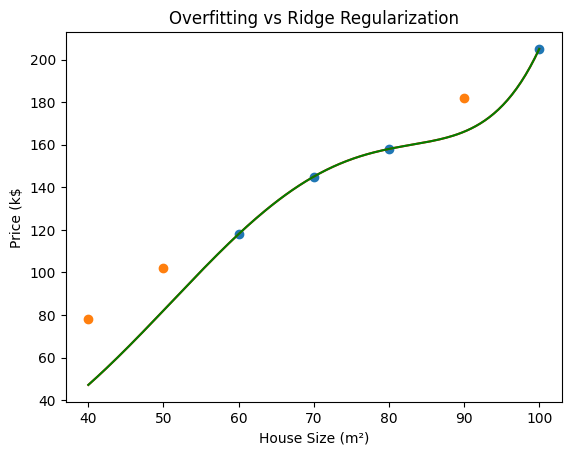

In [30]:
X_line = np.linspace(40, 100, 200).reshape(-1, 1)
X_line_p6 = poly_6.transform(X_line)

y_overfit = overfit_model.predict(X_line_p6)
y_ridge = ridge_model.predict(X_line_p6)

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

plt.plot(X_line, y_overfit, color='red')
plt.plot(X_line, y_ridge, color='green')

plt.xlabel("House Size (m²)")
plt.ylabel("Price (k$")
plt.title("Overfitting vs Ridge Regularization")
plt.show()


In [17]:
y_test_over = overfit_model.predict(X_test_p6)
y_test_ridge = ridge_model.predict(X_test_p6)

print("Overfit MSE:", mean_squared_error(y_test, y_test_over))
print("Ridge MSE:", mean_squared_error(y_test, y_test_ridge))


Overfit MSE: 534.3785111216189
Ridge MSE: 533.9584266584342


alpha ↑  ⇒  penalty ↑  ⇒  coefficients ↓  ⇒  complexity ↓  ⇒  UNDERFITTING

| Model          | شنو كيدير للـ coefficients |
| -------------- | -------------------------- |
| Ridge (L2)     | كيخلّيهم صغار ولكن ≠ 0     |
| **Lasso (L1)** | **كيقدر يطيّحهم لـ 0**  |
